# PHẦN 4 - Kết hợp Canny với các kỹ thuật khác
Mục tiêu: Sử dụng edge map để phân đoạn và nhận dạng hình dạng.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from skimage.color import rgb2gray
from skimage import io

def show_imgs(list_imgs, titles=None, cmap='gray'):
    n = len(list_imgs)
    fig, axes = plt.subplots(1, n, figsize=(5*n,4))
    if n==1:
        axes = [axes]
    for i,img in enumerate(list_imgs):
        axes[i].imshow(img, cmap=cmap)
        if titles and i < len(titles):
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.show()

def find_and_draw_contours(img):
    gray = img if img.ndim==2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    cnts, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(out, cnts, -1, (0,255,0), 2)
    return edges, out, cnts

def approx_and_classify(cnt):
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    v = len(approx)
    if v == 3:
        return 'triangle'
    elif v == 4:
        return 'quadrilateral'
    elif v > 4:
        # check circularity
        area = cv2.contourArea(cnt)
        if area == 0:
            return 'unknown'
        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        if circularity > 0.7:
            return 'circle'
        return 'polygon'
    else:
        return 'unknown'

## Bài toán 1 - Canny + Phân đoạn (dùng contours)
Dùng `cv2.findContours()` trên edge map để tách vùng và vẽ kết quả phân đoạn.

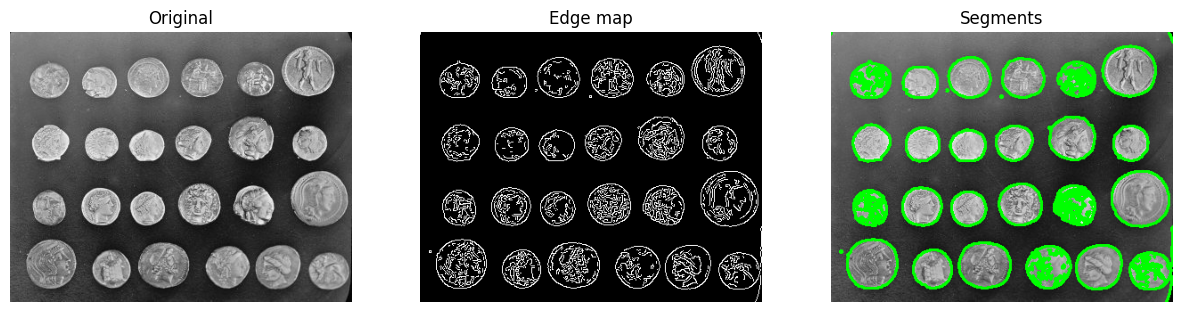

Found contours: 112


In [2]:
img = data.coins()
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
edges, out, cnts = find_and_draw_contours(img_rgb)
show_imgs([img, edges, out], titles=['Original','Edge map','Segments'])
print('Found contours:', len(cnts))

## Bài toán 2 - Canny + Nhận dạng hình dạng
Tìm contour, xấp xỉ bằng `approxPolyDP` và phân loại theo số đỉnh / circularity.

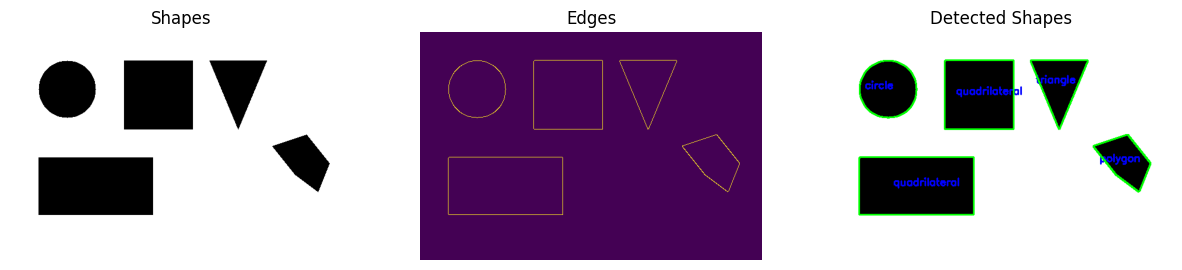

In [14]:
# Tạo ảnh chứa vài hình cơ bản để kiểm tra
canvas = np.zeros((400,600,3), dtype=np.uint8) + 255

# circle
cv2.circle(canvas, (100,100), 50, (0,0,0), -1)

# rectangle 1
cv2.rectangle(canvas, (200,50), (320,170), (0,0,0), -1)

# rectangle 2
cv2.rectangle(canvas, (50,220), (250,320), (0,0,0), -1)

# triangle
pts = np.array([[400,170],[350,50],[450,50]])
cv2.drawContours(canvas, [pts], 0, (0,0,0), -1)

# polygon
pts2 = np.array([[500,250],[460,200],[520,180],[560,230],[540,280]])
cv2.drawContours(canvas, [pts2], 0, (0,0,0), -1)

gray = cv2.cvtColor(canvas, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 50, 150)

cnts, _ = cv2.findContours(edges.copy(),
                           cv2.RETR_EXTERNAL,
                           cv2.CHAIN_APPROX_SIMPLE)

out = canvas.copy()

for c in cnts:
    shape = approx_and_classify(c)

    M = cv2.moments(c)
    if M['m00'] != 0:
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
    else:
        cx, cy = c[0][0]

    cv2.putText(out, shape, (cx-40, cy),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (0,0,255), 2)

    cv2.drawContours(out, [c], -1, (0,255,0), 2)

show_imgs([canvas, edges, out],
          titles=['Shapes', 'Edges', 'Detected Shapes'],
          cmap=None)

## Báo cáo kết quả
- Hiển thị ảnh gốc, edge map, contours và nhãn hình dạng.
- Gợi ý: với ảnh thực tế, cần lọc contour theo diện tích để loại bỏ nhiễu.

## 4. Hiệu quả khi kết hợp

- **Phân đoạn ảnh:** Canny cung cấp edge map tốt để tìm contour bằng `cv2.findContours()`. Kết quả phù hợp để tách vùng có ranh giới rõ ràng, nhưng cần tiền xử lý (blur, threshold, morphological) và lọc contour theo diện tích để loại bỏ các vùng nhiễu nhỏ. Với ảnh thật, thường kết hợp Canny + morphological operations + watershed để có phân đoạn ổn định hơn.

- **Nhận dạng hình dạng:** Sau khi tìm contour, `cv2.approxPolyDP()` cho phép xấp xỉ đa giác, và kiểm tra circularity giúp phát hiện hình tròn. Phương pháp này hoạt động tốt trên các đối tượng sạch, đơn giản; cần lọc theo diện tích/độ tin cậy trên ảnh thực tế để tránh sai lệch do nhiễu hoặc chi tiết phụ.

## 5. Kết luận tổng quát

- **Khi nên dùng Canny:**
  - Ảnh có biên rõ, ít nhiễu hoặc đã được tiền xử lý (blur/denoise).
  - Ứng dụng cần cạnh mảnh, nhanh (ví dụ: tiền xử lý cho phân đoạn, trích xuất contour, nhận dạng hình học).
  - Khi cần kết quả nhạy với ngưỡng và dễ điều chỉnh tham số.

- **Khi không nên dùng Canny (hoặc cần thận trọng):**
  - Ảnh có nhiễu mạnh, họa tiết phức tạp mà không tiền xử lý (sẽ sinh nhiều biên giả).
  - Ảnh có tương phản rất thấp mà không cân bằng (cần equalization/CLAHE trước).
  - Nhiệm vụ cần hiểu ngữ nghĩa vùng (semantic segmentation) — nên dùng phương pháp học sâu.

- **Tóm lược:** Canny là công cụ nhẹ, hiệu quả để trích biên và làm bước tiền xử lý cho phân đoạn/nhận dạng hình dạng; nhưng để ứng dụng thực tế cần kết hợp tiền xử lý (blur/heq), lọc contour và đôi khi thay bằng hoặc kết hợp với phương pháp nâng cao (morphology, watershed, deep learning) tùy độ phức tạp của ảnh.